In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

In [7]:
import pandas as pd

df = pd.read_csv("/home/pamela/Downloads/Coffe_sales.csv")

df.head()

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
0,10,card,38.7,Latte,Morning,Fri,Mar,5,3,2024-03-01,10:15:50.520000
1,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:19:22.539000
2,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:20:18.089000
3,13,card,28.9,Americano,Afternoon,Fri,Mar,5,3,2024-03-01,13:46:33.006000
4,13,card,38.7,Latte,Afternoon,Fri,Mar,5,3,2024-03-01,13:48:14.626000


In [8]:
print("Filas y columnas:", df.shape)

display(df.head())
display(df.tail())

df.info()

Filas y columnas: (3547, 11)


,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
0,10,card,38.7,Latte,Morning,Fri,Mar,5,3,2024-03-01,10:15:50.520000
1,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:19:22.539000
2,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:20:18.089000
3,13,card,28.9,Americano,Afternoon,Fri,Mar,5,3,2024-03-01,13:46:33.006000
4,13,card,38.7,Latte,Afternoon,Fri,Mar,5,3,2024-03-01,13:48:14.626000


,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
3542,10,card,35.76,Cappuccino,Morning,Sun,Mar,7,3,2025-03-23,10:34:54.894000
3543,14,card,35.76,Cocoa,Afternoon,Sun,Mar,7,3,2025-03-23,14:43:37.362000
3544,14,card,35.76,Cocoa,Afternoon,Sun,Mar,7,3,2025-03-23,14:44:16.864000
3545,15,card,25.96,Americano,Afternoon,Sun,Mar,7,3,2025-03-23,15:47:28.723000
3546,18,card,35.76,Latte,Night,Sun,Mar,7,3,2025-03-23,18:11:38.635000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3547 entries, 0 to 3546
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   hour_of_day  3547 non-null   int64  
 1   cash_type    3547 non-null   object 
 2   money        3547 non-null   float64
 3   coffee_name  3547 non-null   object 
 4   Time_of_Day  3547 non-null   object 
 5   Weekday      3547 non-null   object 
 6   Month_name   3547 non-null   object 
 7   Weekdaysort  3547 non-null   int64  
 8   Monthsort    3547 non-null   int64  
 9   Date         3547 non-null   object 
 10  Time         3547 non-null   object 
dtypes: float64(1), int64(3), object(7)
memory usage: 304.9+ KB


In [9]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
hour_of_day,3547.0,NaN,NaN,NaN,14.185791,4.23401,6.0,10.0,14.0,18.0,22.0
cash_type,3547,1,card,3547,NaN,NaN,NaN,NaN,NaN,NaN,NaN
money,3547.0,NaN,NaN,NaN,31.645216,4.877754,18.12,27.92,32.82,35.76,38.7
coffee_name,3547,8,Americano with Milk,809,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Time_of_Day,3547,3,Afternoon,1205,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Weekday,3547,7,Tue,572,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Month_name,3547,12,Mar,494,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Weekdaysort,3547.0,NaN,NaN,NaN,3.845785,1.971501,1.0,2.0,4.0,6.0,7.0
Monthsort,3547.0,NaN,NaN,NaN,6.453905,3.500754,1.0,3.0,7.0,10.0,12.0
Date,3547,381,2024-10-11,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
faltantes = df.isnull().sum().sort_values(ascending=False)

resumen_faltantes = pd.DataFrame({
    "cantidad_faltante": faltantes,
    "porcentaje": (faltantes / len(df) * 100).round(2)
})

resumen_faltantes

,cantidad_faltante,porcentaje
hour_of_day,0,0.0
cash_type,0,0.0
money,0,0.0
coffee_name,0,0.0
Time_of_Day,0,0.0
Weekday,0,0.0
Month_name,0,0.0
Weekdaysort,0,0.0
Monthsort,0,0.0
Date,0,0.0


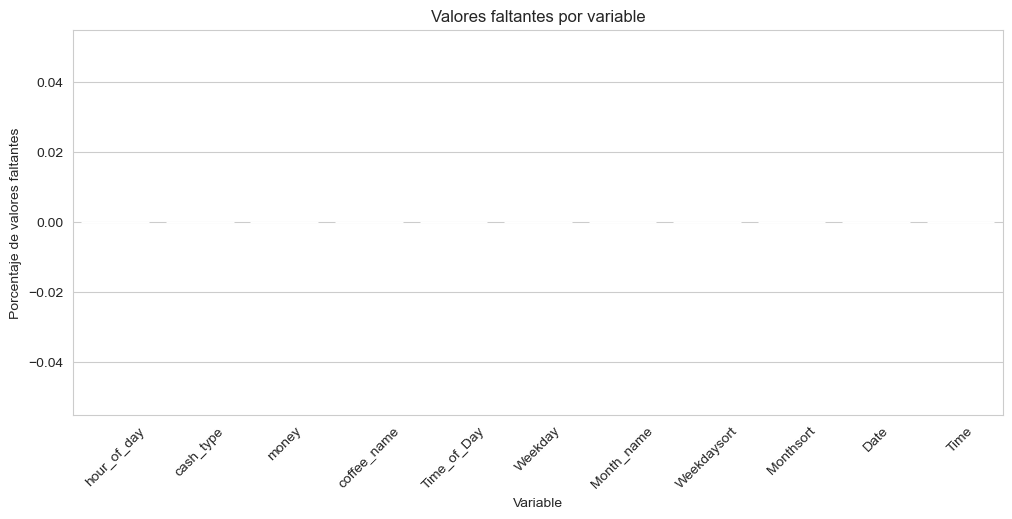

In [11]:
plt.figure(figsize=(12, 5))

sns.barplot(
    x=resumen_faltantes.index,
    y=resumen_faltantes["porcentaje"]
)

plt.xticks(rotation=45)
plt.ylabel("Porcentaje de valores faltantes")
plt.xlabel("Variable")
plt.title("Valores faltantes por variable")
plt.show()

In [12]:
df = df.drop_duplicates().reset_index(drop=True)

print("Tamaño después de eliminar duplicados:", df.shape)

Tamaño después de eliminar duplicados: (3547, 11)


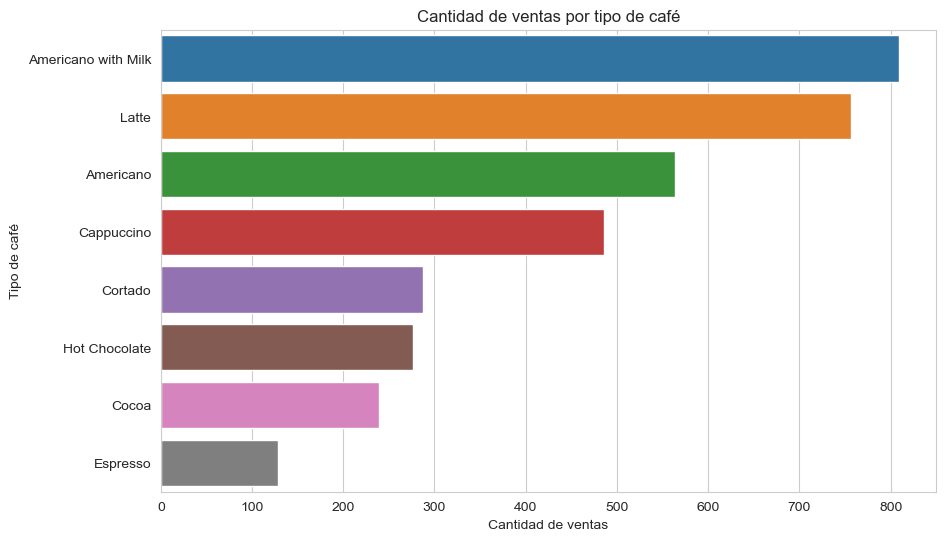

In [13]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    y="coffee_name",
    order=df["coffee_name"].value_counts().index
)

plt.xlabel("Cantidad de ventas")
plt.ylabel("Tipo de café")
plt.title("Cantidad de ventas por tipo de café")
plt.show()

In [14]:
ventas_cafe = (
    df.groupby("coffee_name")["money"]
    .sum()
    .sort_values(ascending=False)
)

ventas_cafe

coffee_name
Latte                  26875.30
Americano with Milk    24751.12
Cappuccino             17439.14
Americano              14650.26
Hot Chocolate           9933.46
Cocoa                   8521.16
Cortado                 7384.86
Espresso                2690.28
Name: money, dtype: float64

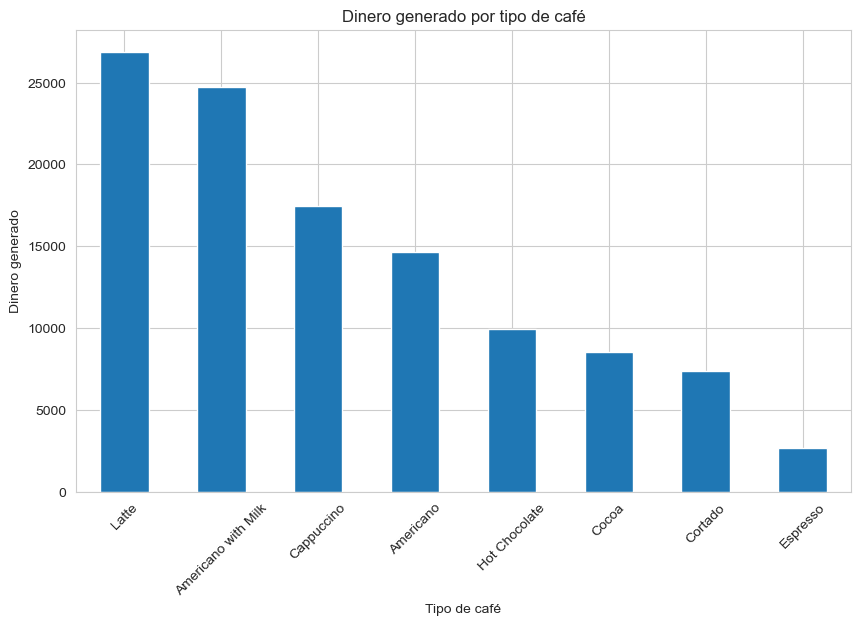

In [15]:
plt.figure(figsize=(10, 6))

ventas_cafe.plot(kind="bar")

plt.xlabel("Tipo de café")
plt.ylabel("Dinero generado")
plt.title("Dinero generado por tipo de café")
plt.xticks(rotation=45)
plt.show()

In [16]:
ventas_hora = df["hour_of_day"].value_counts().sort_index()

ventas_hora

hour_of_day
6       5
7      88
8     235
9     242
10    328
11    283
12    241
13    225
14    225
15    236
16    278
17    237
18    218
19    229
20    169
21    195
22    113
Name: count, dtype: int64

/home/pamela/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/pamela/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


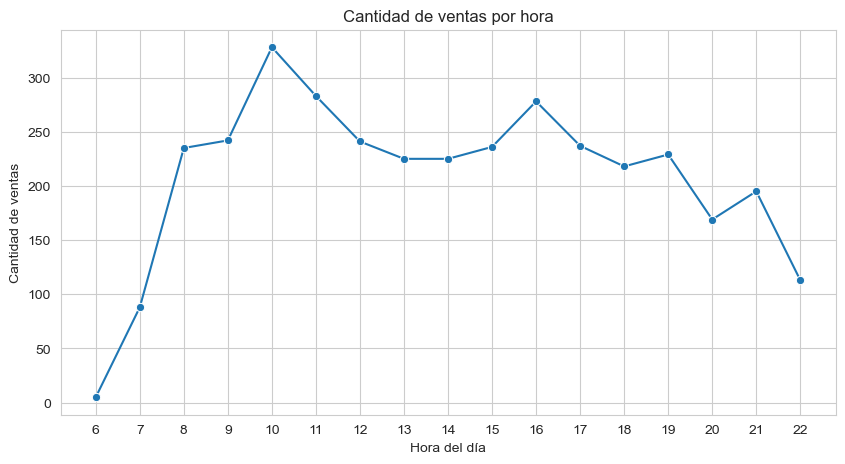

In [17]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    x=ventas_hora.index,
    y=ventas_hora.values,
    marker="o"
)

plt.xlabel("Hora del día")
plt.ylabel("Cantidad de ventas")
plt.title("Cantidad de ventas por hora")
plt.xticks(range(int(df["hour_of_day"].min()), int(df["hour_of_day"].max()) + 1))
plt.show()

In [18]:
ventas_momento = df["Time_of_Day"].value_counts()

ventas_momento

Time_of_Day
Afternoon    1205
Morning      1181
Night        1161
Name: count, dtype: int64

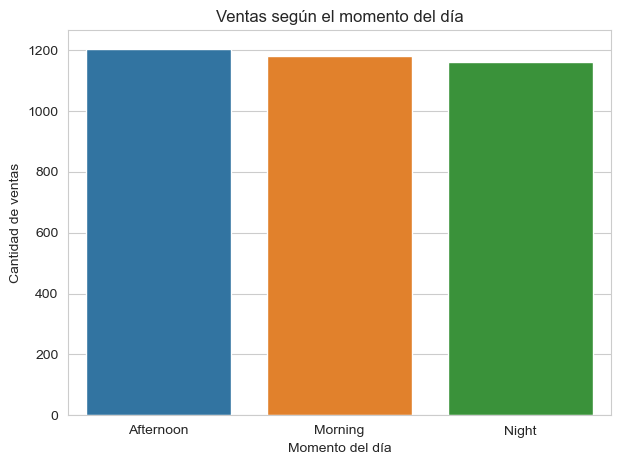

In [19]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Time_of_Day",
    order=df["Time_of_Day"].value_counts().index
)

plt.xlabel("Momento del día")
plt.ylabel("Cantidad de ventas")
plt.title("Ventas según el momento del día")
plt.show()

In [20]:
ventas_dia = df["Weekday"].value_counts()

ventas_dia

Weekday
Tue    572
Mon    544
Fri    532
Thu    510
Wed    500
Sat    470
Sun    419
Name: count, dtype: int64

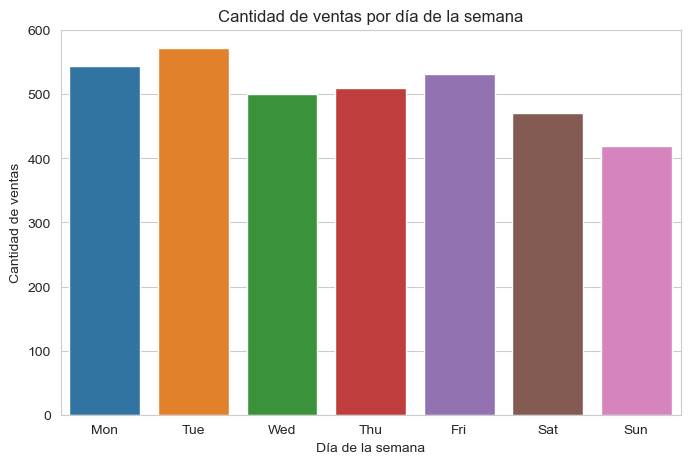

In [21]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Weekday",
    order=["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
)

plt.xlabel("Día de la semana")
plt.ylabel("Cantidad de ventas")
plt.title("Cantidad de ventas por día de la semana")
plt.show()

In [22]:
promedio_cafe = (
    df.groupby("coffee_name")["money"]
    .mean()
    .sort_values(ascending=False)
)

promedio_cafe

coffee_name
Hot Chocolate          35.990797
Cappuccino             35.883004
Cocoa                  35.653389
Latte                  35.502378
Americano with Milk    30.594710
Americano              25.975638
Cortado                25.731220
Espresso               20.854884
Name: money, dtype: float64

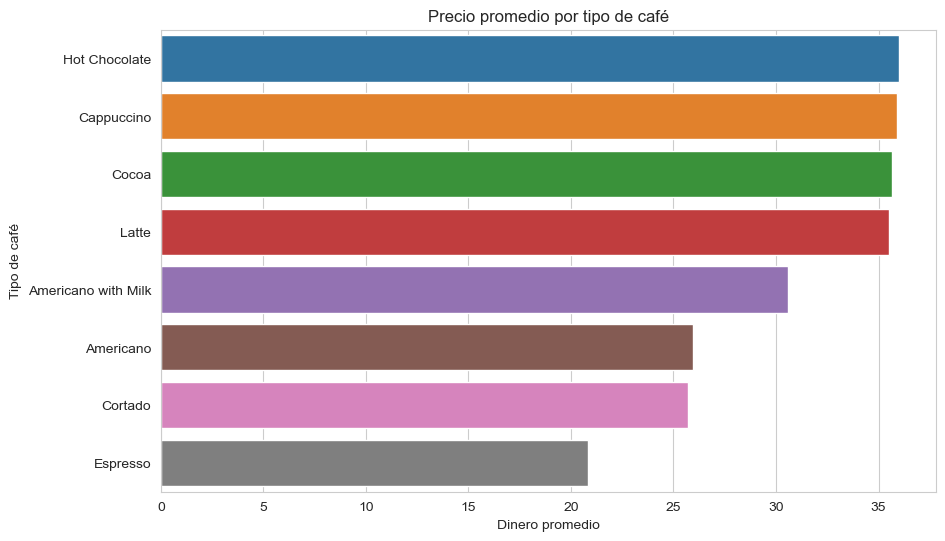

In [23]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=promedio_cafe.values,
    y=promedio_cafe.index
)

plt.xlabel("Dinero promedio")
plt.ylabel("Tipo de café")
plt.title("Precio promedio por tipo de café")
plt.show()

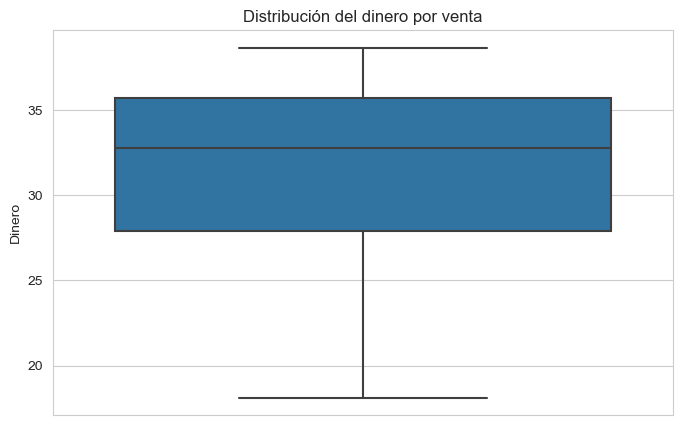

In [24]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    y="money"
)

plt.ylabel("Dinero")
plt.title("Distribución del dinero por venta")
plt.show()

/home/pamela/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


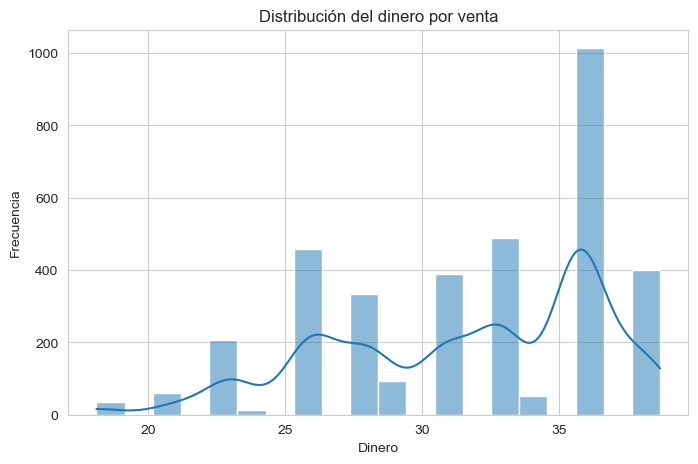

In [25]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="money",
    bins=20,
    kde=True
)

plt.xlabel("Dinero")
plt.ylabel("Frecuencia")
plt.title("Distribución del dinero por venta")
plt.show()

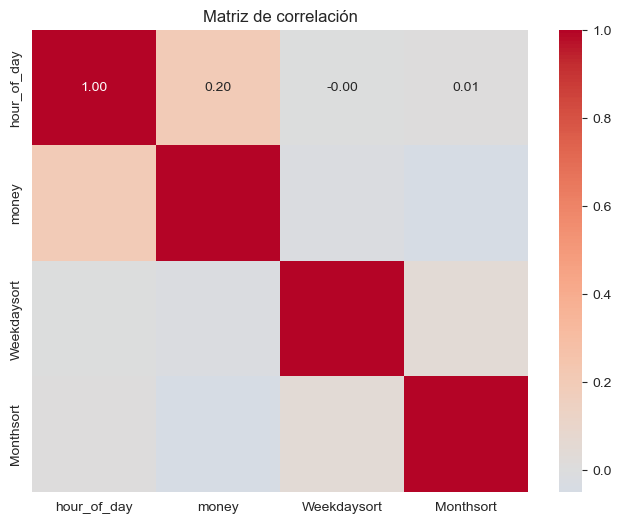

In [26]:
correlacion = df.corr(numeric_only=True)

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlacion,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Matriz de correlación")
plt.show()

In [27]:
tabla_cafe_momento_porcentaje = pd.crosstab(
    df["coffee_name"],
    df["Time_of_Day"],
    normalize="index"
) * 100

tabla_cafe_momento_porcentaje.round(2)

Time_of_Day,Afternoon,Morning,Night
coffee_name,,,
Americano,41.31,38.83,19.86
Americano with Milk,29.54,40.91,29.54
Cappuccino,33.74,25.10,41.15
Cocoa,31.38,24.27,44.35
Cortado,30.66,49.83,19.51
Espresso,43.41,34.11,22.48
Hot Chocolate,28.99,17.75,53.26
Latte,35.67,28.40,35.93


In [28]:
cafe_mas_vendido = df["coffee_name"].value_counts()

print("Café más vendido:")
print(cafe_mas_vendido.idxmax())

print("\nCantidad de ventas:")
print(cafe_mas_vendido.max())

Café más vendido:
Americano with Milk

Cantidad de ventas:
809


In [29]:
dia_mas_ventas = df["Weekday"].value_counts()

print("Día con más ventas:")
print(dia_mas_ventas.idxmax())

print("\nCantidad de ventas:")
print(dia_mas_ventas.max())

Día con más ventas:
Tue

Cantidad de ventas:
572


In [30]:
hora_mas_ventas = df["hour_of_day"].value_counts()

print("Hora con más ventas:")
print(hora_mas_ventas.idxmax())

print("\nCantidad de ventas:")
print(hora_mas_ventas.max())

Hora con más ventas:
10

Cantidad de ventas:
328
